# Storytelling with Dashboards

In the previous lessons, we learned how to design individual charts. But a dashboard is rarely just one chart. It is a collection of visuals meant to drive a business decision. 

The biggest mistake Data Scientists make is treating a dashboard like a "data dump"—throwing ten unrelated charts onto a screen and hoping the stakeholders figure it out. In this lesson, we learn how to structure a dashboard like a narrative story.


A great dashboard follows the exact same narrative arc as a great movie or a newspaper article:
1. **The Context (The Headline)**: What is the current state of the world? (Usually a high-level KPI).
2. **The Conflict (The Drill-Down)**: What went wrong or what changed? (Slicing the data by category or region).
3. **The Resolution (The Actionable Insight)**: Why did it happen, and what should we do next?

Let's set up a Python sandbox to simulate a business scenario. We are analysts at a SaaS (Software as a Service) company. The CEO is panicking because **Total User Growth has flatlined over the last 6 months**. We need to build a visual narrative to explain what is actually happening.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set a clean theme
sns.set_theme(style="white")

# 1. Create a dataset simulating the last 6 months of user growth
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']

# The "Conflict": Basic tier users are leaving, but Pro tier users are growing
basic_users = [5000, 4800, 4200, 3500, 2800, 2000]
pro_users = [1000, 1200, 1500, 1900, 2400, 3000]

# Total users looks flat/declining!
total_users = np.array(basic_users) + np.array(pro_users)

# The "Resolution": Pro users generate massively more revenue
basic_revenue = np.array(basic_users) * 10  # $10/month
pro_revenue = np.array(pro_users) * 50      # $50/month
total_revenue = basic_revenue + pro_revenue

df = pd.DataFrame({
    'Month': months,
    'Basic_Users': basic_users,
    'Pro_Users': pro_users,
    'Total_Users': total_users,
    'Total_Revenue': total_revenue
})

print("✅ SaaS Business Dataset loaded!")

✅ SaaS Business Dataset loaded!


# 1. The Context (The Headline KPI)
The top-left corner of a dashboard is the most valuable real estate on the screen (because in Western cultures, we read left-to-right, top-to-bottom). This is where you put the **Context**. 

The CEO already knows user growth is flat. We must acknowledge this reality immediately so they trust the rest of the dashboard.

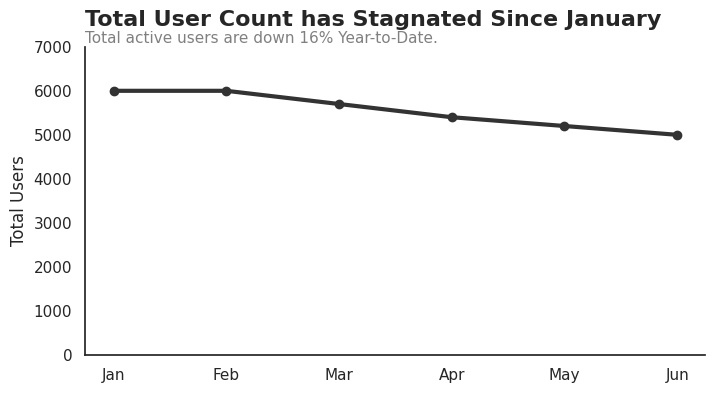

In [2]:
plt.figure(figsize=(8, 4))

# Plot the flatlining Total Users
plt.plot(df['Month'], df['Total_Users'], color='#333333', linewidth=3, marker='o')

# Add context and narrative text
plt.title("Total User Count has Stagnated Since January", fontsize=16, fontweight='bold', loc='left', pad=15)
plt.suptitle("Total active users are down 16% Year-to-Date.", fontsize=11, color='gray', x=0.125, y=0.92, ha='left')

plt.ylim(0, 7000)
plt.ylabel("Total Users")
sns.despine()

plt.show()

*(If we stopped here, the CEO would be terrified. This is the "Data Dump" approach. But we are storytellers, so we move to the next chart.)*

# 2. The Conflict (The Drill-Down)
Once we establish the high-level context, we move the viewer's eye to the right (or slightly down) to introduce the **Conflict**. We need to break that top-level metric apart to see *what* is causing the stagnation.

We will use a stacked bar chart to show the composition of our users.

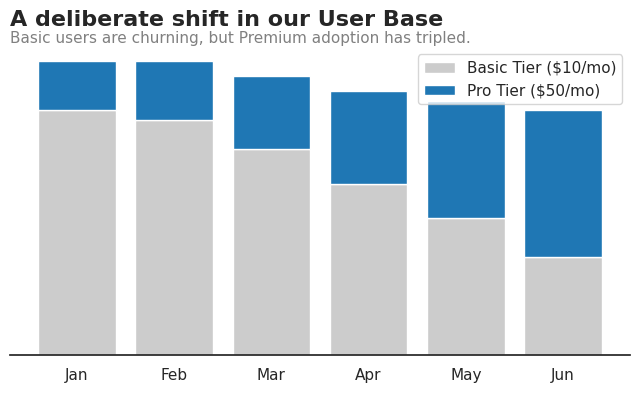

In [3]:
plt.figure(figsize=(8, 4))

# Plot Basic vs Pro users
plt.bar(df['Month'], df['Basic_Users'], label='Basic Tier ($10/mo)', color='#cccccc')
plt.bar(df['Month'], df['Pro_Users'], bottom=df['Basic_Users'], label='Pro Tier ($50/mo)', color='#1f77b4')

plt.title("A deliberate shift in our User Base", fontsize=16, fontweight='bold', loc='left', pad=15)
plt.suptitle("Basic users are churning, but Premium adoption has tripled.", fontsize=11, color='gray', x=0.125, y=0.92, ha='left')

plt.legend(loc='upper right')
sns.despine(left=True)
plt.yticks([]) # Remove Y-axis ticks to reduce noise

plt.show()

*(The story is forming! The CEO now sees that the "stagnation" isn't a failure—it is a structural shift. The cheap users are leaving, and the expensive users are growing.)*

# 3. The Resolution (The Actionable Insight)
We have explained *what* happened, but dashboards exist to drive business decisions. The final chart (usually at the bottom or bottom-right) must show the **Resolution**. Why is this structural shift a good thing, and should we continue doing it?

We map the user shift directly to Revenue.

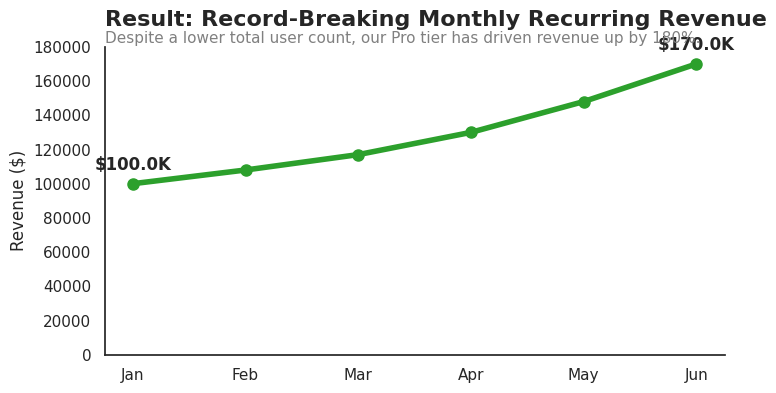

In [4]:
plt.figure(figsize=(8, 4))

# Plot Total Revenue
plt.plot(df['Month'], df['Total_Revenue'], color='#2ca02c', linewidth=4, marker='o', markersize=8)

plt.title("Result: Record-Breaking Monthly Recurring Revenue", fontsize=16, fontweight='bold', loc='left', pad=15)
plt.suptitle("Despite a lower total user count, our Pro tier has driven revenue up by 180%.", fontsize=11, color='gray', x=0.125, y=0.92, ha='left')

# Add direct labels to show the financial growth
for i, txt in enumerate(df['Total_Revenue']):
    if i == 0 or i == 5: # Only label the first and last month to avoid clutter
        plt.annotate(f"${txt/1000}K", (df['Month'][i], df['Total_Revenue'][i]), 
                     textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

plt.ylim(0, 180000)
plt.ylabel("Revenue ($)")
sns.despine()

plt.show()

*(The climax! We started with a terrifying metric (stagnant users), drilled down to the root cause (tier shifting), and resolved it with a massive win (record revenue). The CEO walks away from this dashboard knowing that the marketing strategy is working perfectly.)*

# 4. The Z-Pattern Layout
When you eventually move these charts into a BI tool like Tableau or PowerBI, you arrange them to guide the human eye. 

The most common layout in web design and dashboarding is the **Z-Pattern**:
1. **Top Left**: The big, bold KPI headline (Total Users are flat).
2. **Top Right**: The breakdown or filter (It is because Basic users are leaving).
3. **Bottom Left**: Supporting details or data tables (if needed).
4. **Bottom Right**: The bottom line / final insight (Revenue is skyrocketing).

---

## Real-World Use Case or Analogy:
Think of Storytelling with Dashboards like **The Front Page of a Newspaper**:

* **The Headline (Top Left)**: *"City Hit by Massive Blizzard!"* (The Context). You don't bury this on page 4. It is the biggest, boldest text on the page. 
* **The Photograph (Center/Right)**: A picture showing snow plows clearing the main highway. (The Conflict/Drill-Down). It gives visual depth to the headline and shows exactly where the action is happening.
* **The Article Body (Below)**: *"While roads were closed, city officials report zero accidents due to early preparation."* (The Resolution). You read this last. It provides the final insight and tells you that despite the scary headline, everything is under control.
* **The Dashboard Equivalent**: If a newspaper was designed like a bad dashboard, the headline would just say *"Weather Statistics for Q1,"* followed by a 10-page spreadsheet of barometric pressure readings. No one would read it, and no one would know to stay off the roads.

---